
# Project Success Analytics

This project provides a comprehensive analysis of a synthetic dataset that simulates **project performance and success** metrics. It is designed to demonstrate the skills of a **Business Analyst**, **Program Manager**, or **Data Analyst** by walking through data exploration, feature engineering, and predictive modeling. The dataset includes variables such as team size, budget, risk level, complexity, domain, scope changes, satisfaction ratings, and both planned and actual project durations. From these features, we derive a *success metric* and a *success label* to identify which projects are likely to succeed.

In this notebook, we'll:

1. **Load and inspect the synthetic dataset**
2. **Perform exploratory data analysis (EDA)** with visualizations
3. **Prepare data** for modeling (encoding categorical variables and train/test splits)
4. **Build and evaluate classification models** to predict project success
5. **Build and evaluate regression models** to predict the success metric
6. Summarize findings and discuss potential next steps for deeper analysis

Let's get started!


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error, mean_squared_error, r2_score

# Configure plotting
sns.set(style='whitegrid')

# Load dataset
file_path = '../data/synthetic_project_data.csv'
df = pd.read_csv(file_path)

# Display basic info
print("DataFrame shape:", df.shape)
print("First five rows:")
print(df.head())


DataFrame shape: (500, 16)
First five rows:
   project_id  start_date    end_date  planned_duration_days  \
0           1  2023-08-02  2024-06-06                    360   
1           2  2020-08-16  2021-04-13                    240   
2           3  2020-02-21  2021-11-28                    720   
3           4  2021-07-17  2022-07-21                    390   
4           5  2021-05-16  2021-12-18                    270   

   actual_duration_days  team_size         budget   actual_spent  risk_level  \
0                   309         11  470576.298803  400999.215506           3   
1                   240         24  337221.767230  296331.746339           4   
2                   646         19  282513.315842  318967.537350           1   
3                   369         15  345700.097825  349017.824125           2   
4                   216         12  246052.804405  303293.629712           3   

  complexity     domain  scope_changes  satisfaction_rating  \
0        Low  Marketing    

In [2]:

# Summary statistics for numeric columns
numeric_cols = ['planned_duration_days','actual_duration_days','team_size','budget','actual_spent','risk_level','scope_changes','satisfaction_rating','budget_overrun_percentage','success_metric']
print(df[numeric_cols].describe().T)


                           count           mean            std           min  \
planned_duration_days      500.0     412.920000     192.024009     90.000000   
actual_duration_days       500.0     408.418000     212.790505     65.000000   
team_size                  500.0      17.526000       7.951086      5.000000   
budget                     500.0  278420.400036  126718.758040  51167.760973   
actual_spent               500.0  308098.777688  147707.558478  44734.366806   
risk_level                 500.0       2.954000       1.418417      1.000000   
scope_changes              500.0       4.868000       3.128282      0.000000   
satisfaction_rating        500.0       4.010900       0.651516      1.970000   
budget_overrun_percentage  500.0      10.502700      14.910036    -20.000000   
success_metric             500.0      80.721160      16.553773     24.170000   

                                     25%            50%            75%  \
planned_duration_days         240.000000     

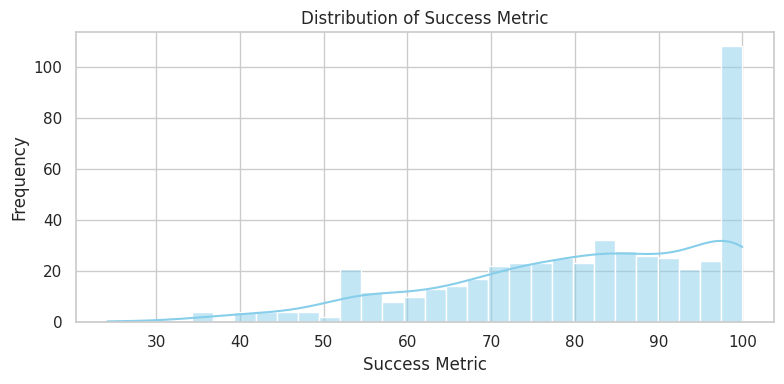

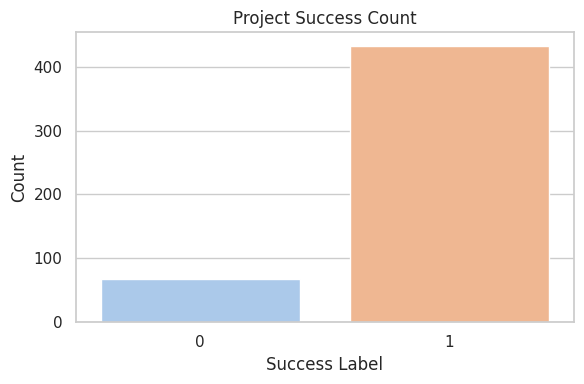

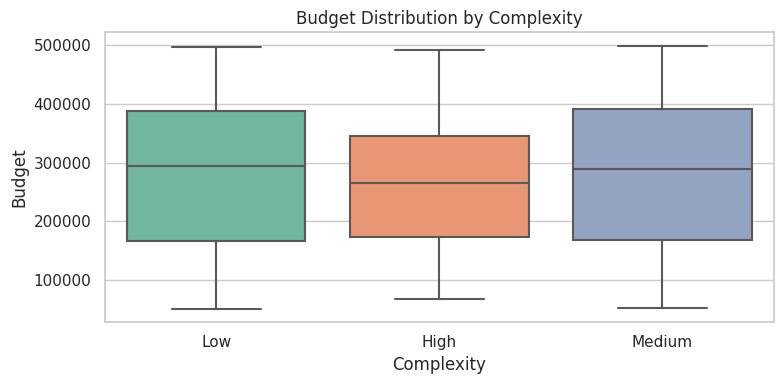

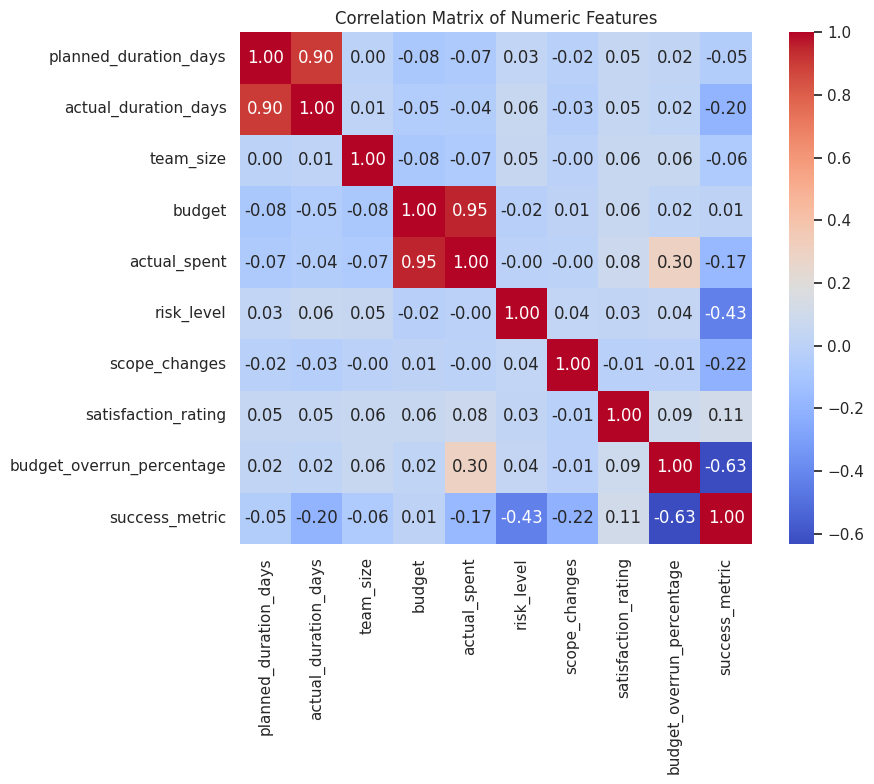

In [3]:

# Distribution of success metric
plt.figure(figsize=(8,4))
sns.histplot(df['success_metric'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Success Metric')
plt.xlabel('Success Metric')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Bar chart of project success counts
plt.figure(figsize=(6,4))
sns.countplot(x='success', data=df, palette='pastel')
plt.title('Project Success Count')
plt.xlabel('Success Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Boxplot of budget by complexity
plt.figure(figsize=(8,4))
sns.boxplot(x='complexity', y='budget', data=df, palette='Set2')
plt.title('Budget Distribution by Complexity')
plt.xlabel('Complexity')
plt.ylabel('Budget')
plt.tight_layout()
plt.show()

# Correlation heatmap for numeric features
plt.figure(figsize=(10,8))
corr = df[['planned_duration_days','actual_duration_days','team_size','budget','actual_spent','risk_level','scope_changes','satisfaction_rating','budget_overrun_percentage','success_metric']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()


Logistic Regression Accuracy: 0.86
Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.50      0.36      0.42        14
           1       0.90      0.94      0.92        86

    accuracy                           0.86       100
   macro avg       0.70      0.65      0.67       100
weighted avg       0.84      0.86      0.85       100



Random Forest Accuracy: 0.91
Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      0.36      0.53        14
           1       0.91      1.00      0.95        86

    accuracy                           0.91       100
   macro avg       0.95      0.68      0.74       100
weighted avg       0.92      0.91      0.89       100



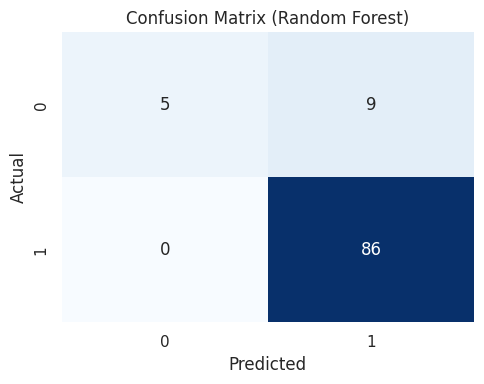

In [4]:

# Prepare features and target for classification
X = df.drop(['success', 'success_metric', 'start_date', 'end_date'], axis=1)
y = df['success']

# Identify categorical and numeric columns
categorical_cols = ['complexity','domain']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Preprocess: OneHotEncode categorical variables and keep numeric variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ])

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Logistic Regression model pipeline
log_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                             ('classifier', LogisticRegression(max_iter=1000))])

# Fit logistic regression
log_reg_pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred_lr = log_reg_pipeline.predict(X_test)

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print('Classification Report (Logistic Regression):')
print(classification_report(y_test, y_pred_lr))

# Random Forest classifier pipeline
rf_classifier = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))])

rf_classifier.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_classifier.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Classification Report (Random Forest):')
print(classification_report(y_test, y_pred_rf))

# Confusion matrix heatmap for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


Linear Regression MAE: 3.385473371459341
Linear Regression RMSE: 4.779320647073521
Linear Regression R^2: 0.9124046897358016


Random Forest Regressor MAE: 5.953076500000003
Random Forest Regressor RMSE: 7.461243130710526
Random Forest Regressor R^2: 0.7865132615673684


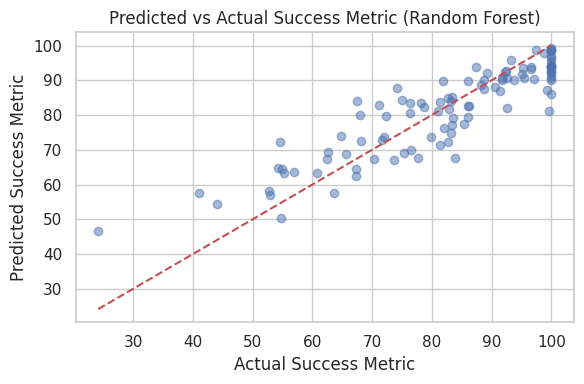

In [5]:

# Prepare target for regression
X_reg = df.drop(['success_metric','success','start_date','end_date'], axis=1)
y_reg = df['success_metric']

categorical_cols_reg = ['complexity','domain']
numeric_cols_reg = [col for col in X_reg.columns if col not in categorical_cols_reg]

# Preprocess
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_reg),
        ('num', 'passthrough', numeric_cols_reg)
    ])

# Train/test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Linear Regression pipeline
lin_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor_reg),
                             ('regressor', LinearRegression())])

lin_reg_pipeline.fit(X_train_reg, y_train_reg)

# Predict
y_pred_lin = lin_reg_pipeline.predict(X_test_reg)

# Evaluate
mae_lin = mean_absolute_error(y_test_reg, y_pred_lin)
rmse_lin = mean_squared_error(y_test_reg, y_pred_lin, squared=False)
r2_lin = r2_score(y_test_reg, y_pred_lin)

print('Linear Regression MAE:', mae_lin)
print('Linear Regression RMSE:', rmse_lin)
print('Linear Regression R^2:', r2_lin)

# Random Forest Regressor pipeline
rf_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor_reg),
                            ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))])

rf_reg_pipeline.fit(X_train_reg, y_train_reg)

# Predict
y_pred_rf = rf_reg_pipeline.predict(X_test_reg)

# Evaluate
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
rmse_rf = mean_squared_error(y_test_reg, y_pred_rf, squared=False)
r2_rf = r2_score(y_test_reg, y_pred_rf)

print('Random Forest Regressor MAE:', mae_rf)
print('Random Forest Regressor RMSE:', rmse_rf)
print('Random Forest Regressor R^2:', r2_rf)

# Scatter plot predicted vs actual for Random Forest
plt.figure(figsize=(6,4))
plt.scatter(y_test_reg, y_pred_rf, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.title('Predicted vs Actual Success Metric (Random Forest)')
plt.xlabel('Actual Success Metric')
plt.ylabel('Predicted Success Metric')
plt.tight_layout()
plt.show()



## Conclusion

This synthetic project dataset demonstrates how various project attributes—such as team size, budget, risk level, scope changes, complexity, and satisfaction ratings—affect both the probability of success and the overall success metric. Through exploratory data analysis, we observed distinct patterns in how these factors influence outcomes. For example, higher risk levels and increased scope changes tend to reduce the success metric, while greater satisfaction ratings contribute positively.

Our modeling exercise showed that a **Random Forest Classifier** achieved higher accuracy than Logistic Regression when predicting the binary success label. Meanwhile, the **Random Forest Regressor** captured non-linear relationships in the data better than a simple Linear Regression model, resulting in lower error metrics and a higher R^2 score for predicting the continuous success metric.

In a real-world setting, you could extend this analysis by:

- Performing cross-validation and hyperparameter tuning on the models
- Exploring feature importance from the Random Forest models
- Conducting time-series analysis on project start and end dates
- Integrating additional external factors (e.g., economic indicators or team experience)

This project serves as a portfolio-ready example to showcase your ability to generate synthetic data, perform comprehensive EDA, build and evaluate predictive models, and clearly communicate your findings. Feel free to adapt and expand upon this template for your own projects!
